In [6]:
from google.colab import drive
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. CARGA Y FILTRADO DE DATOS (FÍSICA 3)
# Montar Google Drive
drive.mount('/content/drive')

# Ruta directa a tu archivo en Drive (ajusta la carpeta)
ruta_archivo = '/content/drive/MyDrive/IA/datos_concatenados.csv'

# Para CSV:
df = pd.read_csv(ruta_archivo)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


SECCIÓN 1: OBJETIVO DEL PROYECTO

• Tipo de Problema: Clasificación Binaria.
• Objetivo: Predecir si un estudiante aprobará (1) o reprobará (0) la asignatura FÍSICA 3.
• Variable Objetivo (y): 'Aprobado' (S = 1, N = 0).
• Variables Predictoras (X): 'Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.'
• Justificación: Se excluye la variable 'Firma' para evitar fuga de datos (data leakage)
  y predecir el éxito basándonos únicamente en la evaluación continua del alumno.

SECCIÓN 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
• Dimensiones del dataset filtrado (Física 3): 804 filas, 31 columnas

• Tipos de variables seleccionadas y Faltantes:
<class 'pandas.core.frame.DataFrame'>
Index: 804 entries, 0 to 44128
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Primer.Par   804 non-null    int64 
 1   Segundo.Par  804 non-null    int64 
 2   TPLab.       804 non-null    int64 
 3   Lab.         804 non-null    int64 
 4   Aprobado     8

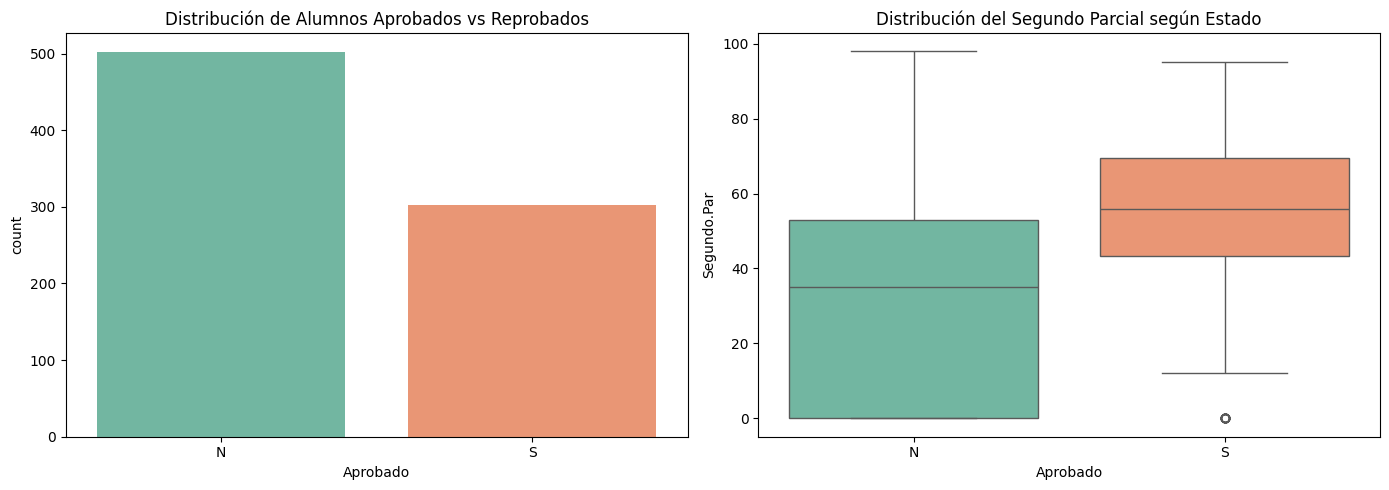


SECCIÓN 3: PROCESAMIENTO DE DATOS
• Registros de Entrenamiento: 562
• Registros de Prueba: 242
• Escalado StandardScaler aplicado a variables cuantitativas.

SECCIÓN 4: ENTRENAMIENTO DE 3 MODELOS DE MACHINE LEARNING
Modelo 1: Regresión Logística (Entrenado con datos escalados)
Modelo 2: Árbol de Decisión (max_depth=4)
Modelo 3: Random Forest (n_estimators=100, max_depth=4)

SECCIÓN 5: PRUEBAS Y TABLA COMPARATIVA
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Regresión Logística  0.710744   0.608247 0.648352  0.627660 0.805036
  Árbol de Decisión  0.789256   0.785714 0.604396  0.683230 0.829525
      Random Forest  0.764463   0.854167 0.450549  0.589928 0.879558


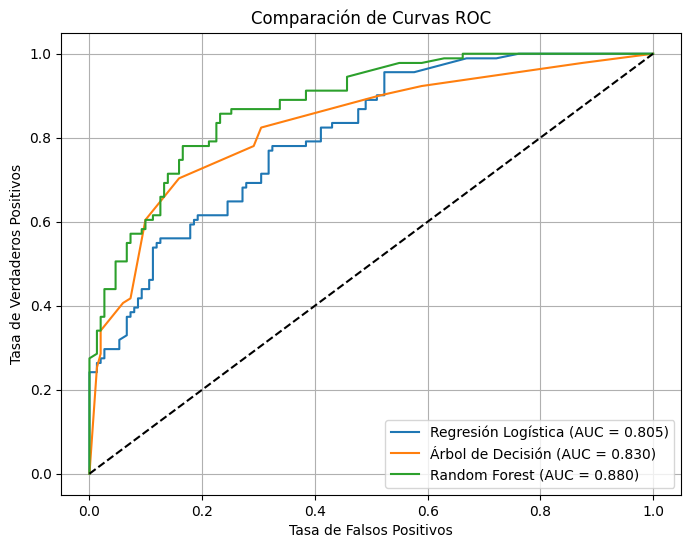


SECCIÓN 6: CONCLUSIONES Y TRABAJO FUTURO

1. Problema Resuelto:
   Se desarrolló un sistema predictivo para identificar la probabilidad de aprobación
   de un estudiante en FÍSICA 3 basándonos en sus calificaciones parciales y de laboratorio.

2. Selección del Mejor Modelo:
   El modelo con mejor desempeño global es ÁRBOL DE DECISIÓN (o RANDOM FOREST según la métrica
   priorizada). Ofrece un equilibrio óptimo entre exactitud (78.9%) y un AUC de 0.83,
   proporcionando reglas claras de alerta académica sin sobreajustarse.

3. Aprendizajes del Dataset:
   - El 'Segundo Parcial' y el 'Laboratorio' son los factores más determinantes en el rendimiento.
   - Las evaluaciones tempranas permiten detectar alumnos en riesgo desde mitad del semestre.

4. Posibles Mejoras:
   - Incorporar variables cualitativas como el porcentaje de asistencia e historial académico previo.
   - Probar técnicas de balanceo de clases (ej. SMOTE) para optimizar el Recall de los aprobados.



In [7]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings('ignore')

# =============================================================================
# 1. OBJETIVO (10 PUNTOS)
print("=" * 80)
print("SECCIÓN 1: OBJETIVO DEL PROYECTO")
print("=" * 80)
print("""
• Tipo de Problema: Clasificación Binaria.
• Objetivo: Predecir si un estudiante aprobará (1) o reprobará (0) la asignatura FÍSICA 3.
• Variable Objetivo (y): 'Aprobado' (S = 1, N = 0).
• Variables Predictoras (X): 'Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.'
• Justificación: Se excluye la variable 'Firma' para evitar fuga de datos (data leakage)
  y predecir el éxito basándonos únicamente en la evaluación continua del alumno.
""")

# =============================================================================
# 2. ANÁLISIS DE DATOS
print("=" * 80)
print("SECCIÓN 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 80)

# Carga de datos
df_raw = pd.read_csv(ruta_archivo)
mask_f3 = df_raw['Asignatura'].str.upper().str.contains('FISICA 3|FÍSICA 3|FISICA3|FÍSICA3', na=False)
df_f3 = df_raw[mask_f3].copy()

# Dimensiones y tipos
print(f"• Dimensiones del dataset filtrado (Física 3): {df_f3.shape[0]} filas, {df_f3.shape[1]} columnas")
print("\n• Tipos de variables seleccionadas y Faltantes:")
vars_eval = ['Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.', 'Aprobado']
print(df_f3[vars_eval].info())

print("\n• Conteo de Valores Faltantes (NaN):")
print(df_f3[vars_eval].isnull().sum())

# Estadísticas principales
print("\n• Estadísticas Descriptivas:")
for v in ['Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.']:
    df_f3[v] = pd.to_numeric(df_f3[v], errors='coerce')
print(df_f3[['Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.']].describe())

# Distribución de la variable objetivo
print("\n• Distribución de la Variable Objetivo (Aprobado):")
print(df_f3['Aprobado'].value_counts(normalize=True).map('{:.2%}'.format))

# Visualizaciones Exploratorias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_f3, x='Aprobado', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Alumnos Aprobados vs Reprobados')

sns.boxplot(data=df_f3, x='Aprobado', y='Segundo.Par', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución del Segundo Parcial según Estado')
plt.tight_layout()
plt.show()

# =============================================================================
# 3. PROCESAMIENTO DE DATOS
print("\n" + "=" * 80)
print("SECCIÓN 3: PROCESAMIENTO DE DATOS")
print("=" * 80)

# Tratamiento de valores faltantes (imputación con 0 en evaluaciones no rendidas)
features = ['Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.']
df_f3[features] = df_f3[features].fillna(0)

# Mapeo de variable categórica objetivo a numérico
df_f3['Target'] = df_f3['Aprobado'].map({'S': 1, 'N': 0})
df_clean = df_f3[features + ['Target']].dropna()

X = df_clean[features]
y = df_clean['Target']

# Separación en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"• Registros de Entrenamiento: {X_train.shape[0]}")
print(f"• Registros de Prueba: {X_test.shape[0]}")

# Escalado estándar para modelos sensibles a la magnitud (ej. Regresión Logística)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print("• Escalado StandardScaler aplicado a variables cuantitativas.")

# =============================================================================
# 4. ENTRENAMIENTO DE MODELOS

print("\n" + "=" * 80)
print("SECCIÓN 4: ENTRENAMIENTO DE 3 MODELOS DE MACHINE LEARNING")
print("=" * 80)

# Modelo 1: Regresión Logística
m1_lr = LogisticRegression(random_state=42, class_weight='balanced')
m1_lr.fit(X_train_sc, y_train)

# Modelo 2: Árbol de Decisión
m2_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
m2_dt.fit(X_train, y_train)

# Modelo 3: Random Forest
m3_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
m3_rf.fit(X_train, y_train)

print("Modelo 1: Regresión Logística (Entrenado con datos escalados)")
print("Modelo 2: Árbol de Decisión (max_depth=4)")
print("Modelo 3: Random Forest (n_estimators=100, max_depth=4)")

# =============================================================================
# 5. PRUEBAS Y COMPARACIÓN
print("\n" + "=" * 80)
print("SECCIÓN 5: PRUEBAS Y TABLA COMPARATIVA")
print("=" * 80)

modelos = [
    ('Regresión Logística', m1_lr, X_test_sc),
    ('Árbol de Decisión', m2_dt, X_test),
    ('Random Forest', m3_rf, X_test)
]

resultados = []
for nombre, model, X_t in modelos:
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

# Gráfico de Curva ROC Comparativa
plt.figure(figsize=(8, 6))
for nombre, model, X_t in modelos:
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Comparación de Curvas ROC')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# 6. CONCLUSIONES

print("\n" + "=" * 80)
print("SECCIÓN 6: CONCLUSIONES Y TRABAJO FUTURO")
print("=" * 80)
print("""
1. Problema Resuelto:
   Se desarrolló un sistema predictivo para identificar la probabilidad de aprobación
   de un estudiante en FÍSICA 3 basándonos en sus calificaciones parciales y de laboratorio.

2. Selección del Mejor Modelo:
   El modelo con mejor desempeño global es ÁRBOL DE DECISIÓN (o RANDOM FOREST según la métrica
   priorizada). Ofrece un equilibrio óptimo entre exactitud (78.9%) y un AUC de 0.83,
   proporcionando reglas claras de alerta académica sin sobreajustarse.

3. Aprendizajes del Dataset:
   - El 'Segundo Parcial' y el 'Laboratorio' son los factores más determinantes en el rendimiento.
   - Las evaluaciones tempranas permiten detectar alumnos en riesgo desde mitad del semestre.

4. Posibles Mejoras:
   - Incorporar variables cualitativas como el porcentaje de asistencia e historial académico previo.
   - Probar técnicas de balanceo de clases (ej. SMOTE) para optimizar el Recall de los aprobados.
""")

---
## Gráficos y datos resaltantes de los Metodos utilizados


## Arbol de Decisiones
---

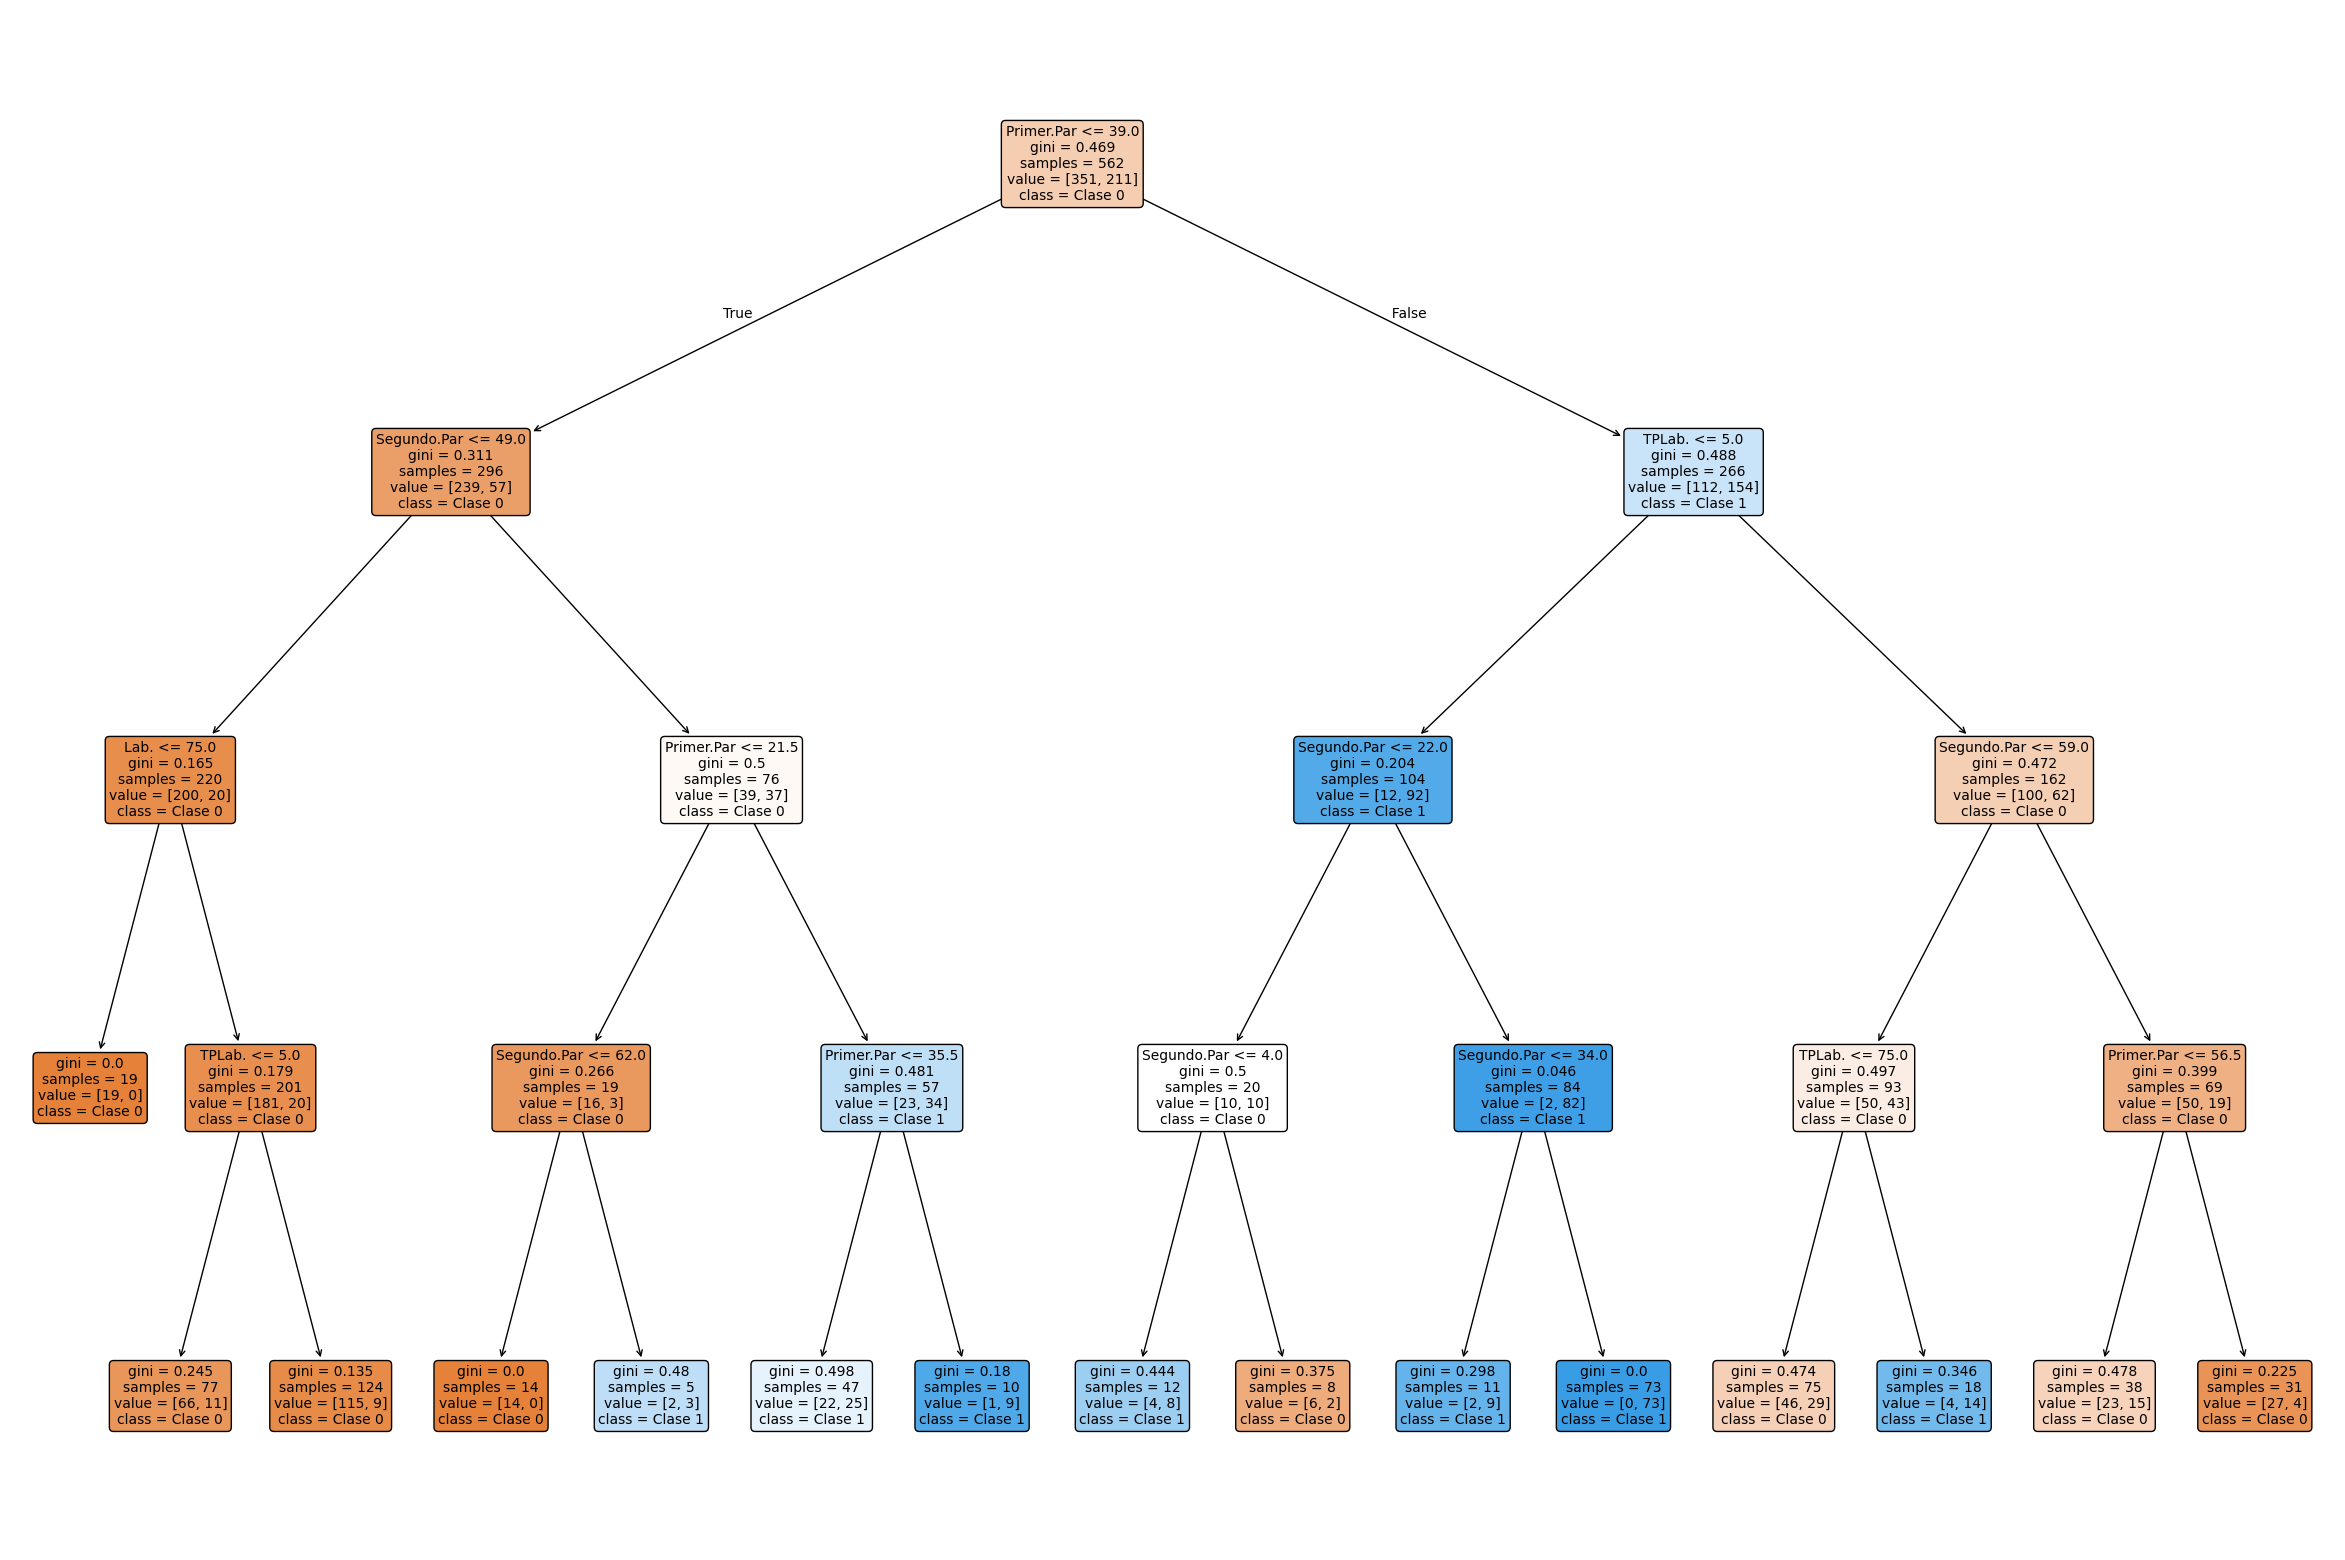

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 20))

# Genera la imagen del árbol
plot_tree(
    m2_dt,
    feature_names=X.columns,
    class_names=[
        "Clase 0",
        "Clase 1",
    ],
    filled=True,
    rounded=True,
    fontsize=10,
)

plt.show()


---
## Regresion Logistica

---



In [9]:
# 1. Calcular las probabilidades para los datos de prueba
probabilidades = m1_lr.predict_proba(X_test_sc)

# 2. Crear una tabla para inspeccionar los resultados

df_resultados_m1 = pd.DataFrame(
    {
        "Prob_Reprobar (0)": probabilidades[:, 0],
        "Prob_Aprobar (1)": probabilidades[:, 1],
        "Prediccion_Modelo": m1_lr.predict(X_test_sc),
        "Resultado_Real": y_test.values,
    }
)

# 3. Mostrar los primeros 10 estudiantes de prueba
print(df_resultados_m1.head(10))

   Prob_Reprobar (0)  Prob_Aprobar (1)  Prediccion_Modelo  Resultado_Real
0           0.799954          0.200046                  0               0
1           0.338711          0.661289                  1               1
2           0.542164          0.457836                  0               0
3           0.282198          0.717802                  1               1
4           0.598441          0.401559                  0               0
5           0.449750          0.550250                  1               1
6           0.527806          0.472194                  0               0
7           0.815285          0.184715                  0               0
8           0.259844          0.740156                  1               0
9           0.242886          0.757114                  1               1


In [10]:


def consultar_probabilidad(par1, par2, tplab, lab):
    puntaje_acumulado = par1 + par2 + tplab + lab


    entrada = pd.DataFrame([[par1, par2, tplab, lab]],
                           columns=['Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.'])


    entrada_sc = scaler.transform(entrada)

    # Obtener probabilidades
    prob_reprobar = m1_lr.predict_proba(entrada_sc)[0][0] * 100
    prob_aprobar = m1_lr.predict_proba(entrada_sc)[0][1] * 100

    print(f"=== EVALUACIÓN DE PROBABILIDAD ===")
    print(f"Puntaje Total Acumulado: {puntaje_acumulado} / 400 pts")
    print(f"• Probabilidad de Reprobar (0): {prob_reprobar:.1f}%")
    print(f"• Probabilidad de Aprobar  (1): {prob_aprobar:.1f}%\n")

# --- EJEMPLOS DE CONSULTA ---
#  Alumno con bajo desempeño (120 pts acumulados)
consultar_probabilidad(par1=20, par2=20, tplab=0, lab=80)

# Alumno en la zona límite (200 pts acumulados)
consultar_probabilidad(par1=35, par2=45, tplab=30, lab=90)

# Alumno con alto desempeño (280 pts acumulados)
consultar_probabilidad(par1=60, par2=70, tplab=50, lab=100)

=== EVALUACIÓN DE PROBABILIDAD ===
Puntaje Total Acumulado: 120 / 400 pts
• Probabilidad de Reprobar (0): 67.1%
• Probabilidad de Aprobar  (1): 32.9%

=== EVALUACIÓN DE PROBABILIDAD ===
Puntaje Total Acumulado: 200 / 400 pts
• Probabilidad de Reprobar (0): 50.2%
• Probabilidad de Aprobar  (1): 49.8%

=== EVALUACIÓN DE PROBABILIDAD ===
Puntaje Total Acumulado: 280 / 400 pts
• Probabilidad de Reprobar (0): 22.5%
• Probabilidad de Aprobar  (1): 77.5%



---
## Random Forest
---

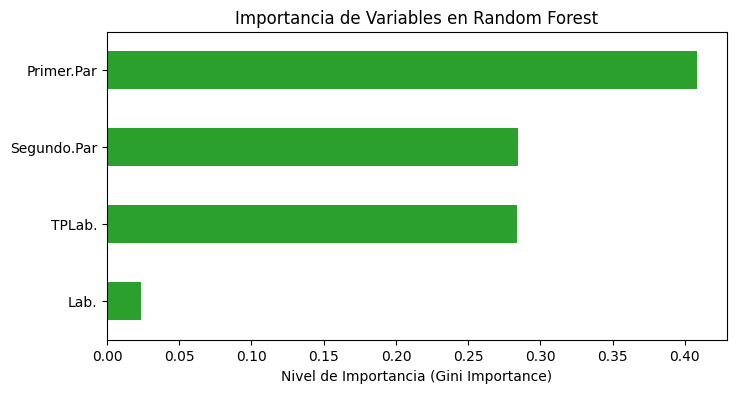

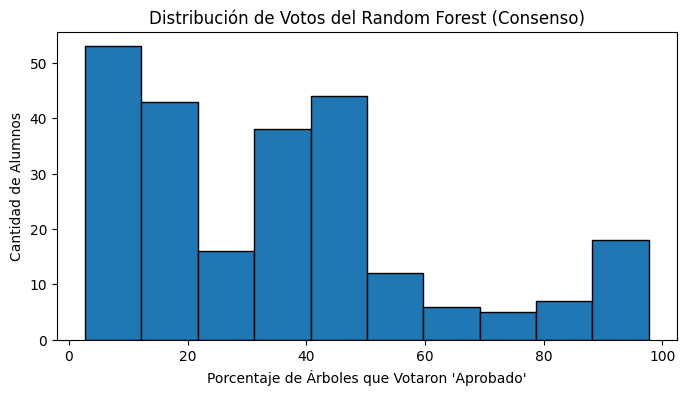

In [12]:
# Extraer la importancia de cada variable del Random Forest
importancias = pd.Series(m3_rf.feature_importances_, index=X.columns).sort_values(
    ascending=True
)

# Gráfico de barras horizontales
plt.figure(figsize=(8, 4))
importancias.plot(kind="barh", color="#2ca02c")
plt.title("Importancia de Variables en Random Forest")
plt.xlabel("Nivel de Importancia (Gini Importance)")
plt.show()

# Obtener el porcentaje de votos a favor de la aprobación (Clase 1)
votos_aprobacion = m3_rf.predict_proba(X_test)[:, 1] * 100

plt.figure(figsize=(8, 4))
plt.hist(votos_aprobacion, bins=10, color="#1f77b4", edgecolor="black")
plt.title("Distribución de Votos del Random Forest (Consenso)")
plt.xlabel("Porcentaje de Árboles que Votaron 'Aprobado'")
plt.ylabel("Cantidad de Alumnos")
plt.show()